In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

df = pd.read_csv('car_price_prediction.csv')

#Analise de dados geral EDA

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [46]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [47]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## Limpeza de alguns dados como Mileage

In [48]:
df["Mileage"] = df["Mileage"].str.extract("(\d+)").astype(int)
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4


<Axes: xlabel='Price', ylabel='Count'>

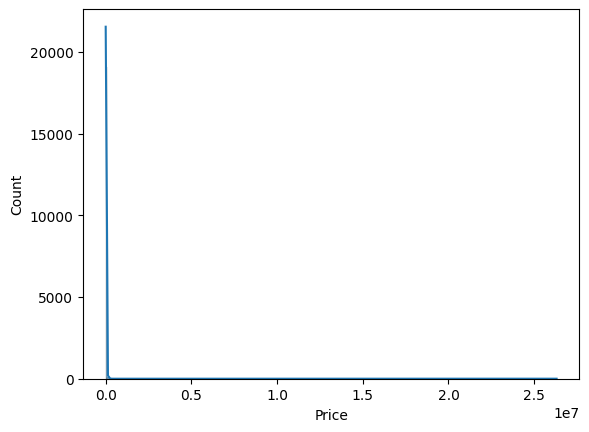

In [49]:
sns.histplot(df["Price"],kde=True)

<Axes: xlabel='Mileage', ylabel='Price'>

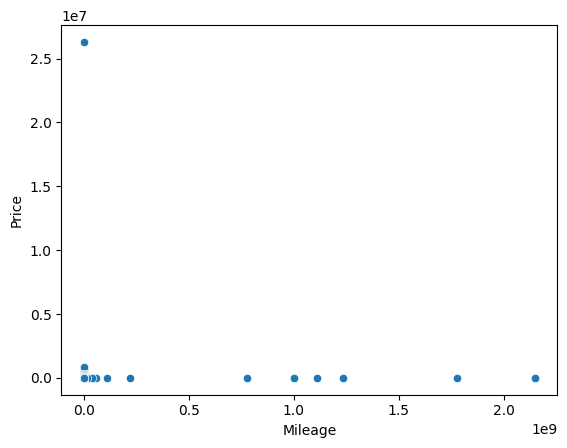

In [53]:
sns.scatterplot(x=df["Mileage"],y=df["Price"])

###Analisando os dois graficos é possivel ver valores absurdos, tanto para preco como Km. entao vamos limitar dentro de um padrao e rever os graficos.

In [61]:
df = df[(df["Mileage"] <=500000) & (df["Price"] <=1000000)]

<Axes: xlabel='Price', ylabel='Count'>

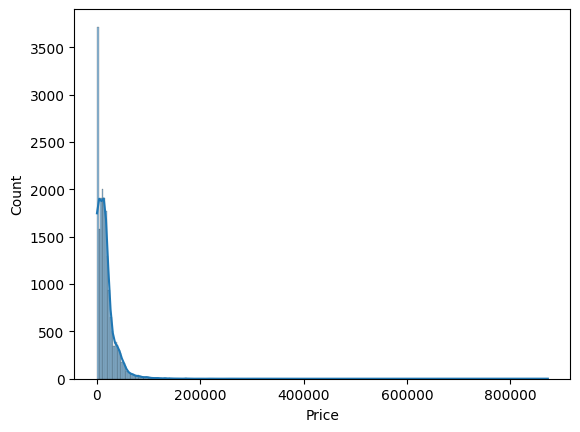

In [62]:
sns.histplot(df["Price"],kde=True)

In [72]:
df.nlargest(5,"Price")
#preco maximo dentro do padrao

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
8541,45761204,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4,2531,8.0,Tiptronic,4x4,04-May,Left wheel,Black,0
1225,45795524,627220,-,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3 Turbo,0,8.0,Tiptronic,4x4,04-May,Left wheel,Black,12
5008,45810285,308906,1694,PORSCHE,911,2016,Coupe,Yes,Petrol,4,8690,6.0,Automatic,Rear,02-Mar,Left wheel,Black,12
9367,45229113,297930,-,MERCEDES-BENZ,AMG GT S,2015,Coupe,Yes,Petrol,4.0 Turbo,20000,8.0,Tiptronic,Rear,02-Mar,Left wheel,White,16
14839,45792307,297930,-,LAND ROVER,Range Rover Vogue,2019,Jeep,Yes,Diesel,3.0 Turbo,4500,8.0,Tiptronic,4x4,04-May,Left wheel,Black,12


<Axes: xlabel='Mileage', ylabel='Price'>

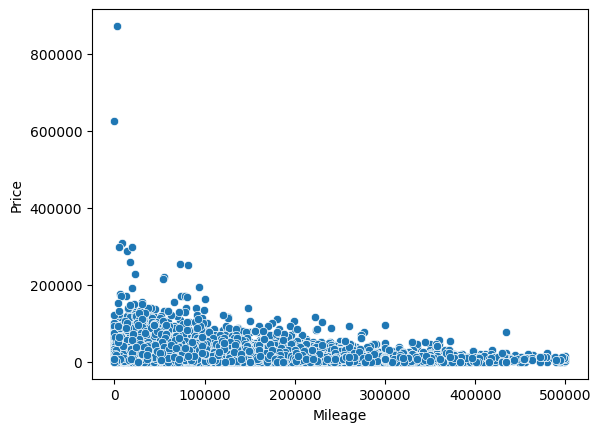

In [73]:
sns.scatterplot(x=df["Mileage"],y=df["Price"])

## limpeza de variaveis nao uteis do banco de dados
###ajustes em parametos

In [75]:
df["Doors"].unique()

<StringArray>
['04-May', '02-Mar', '>5']
Length: 3, dtype: str

In [76]:
mapa = {
    '04-May' : 4, 
    '02-Mar': 2, 
    '>5': 6
}
df["Doors"] = df["Doors"].map(mapa)
#ajustando a quantidade de portas

In [78]:
df["Engine volume"] = df["Engine volume"].str.extract("(\d+)").astype(float)
#removendo possiveis valores nao numericos

In [82]:
df["Levy"].unique()

<StringArray>
[ '1399',  '1018',     '-',   '862',   '446',   '891',   '761',   '751',
   '394',  '1053',
 ...
  '1171',  '1365',  '1531',  '1590', '11706',  '2308',  '4860',  '1641',
  '1045',  '1901']
Length: 557, dtype: str

In [85]:
(df["Levy"] == "-").sum()
# falta de valores dessa coluna corresponde equivalante a 30%. alto teor para diferenciar nos calculos ml. sera removido

np.int64(5723)

In [86]:
df.drop(columns=["Levy","Wheel"])

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.0,186005,6.0,Automatic,4x4,4,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,4,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.0,200000,4.0,Variator,Front,4,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.0,168966,4.0,Automatic,4x4,4,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.0,91901,4.0,Automatic,Front,4,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0,300000,4.0,Manual,Rear,2,Silver,5
19233,45778856,15681,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.0,161600,4.0,Tiptronic,Front,4,Red,8
19234,45804997,26108,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,4.0,Automatic,Front,4,Grey,4
19235,45793526,5331,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2.0,51258,4.0,Automatic,Front,4,Black,4


## Verificao de Carros duplicados na planilha

In [89]:
df["ID"].duplicated().sum()
#existencia de 309 carros duplicados

np.int64(309)

In [93]:
df[df["ID"].duplicated(keep=False)].sort_values("ID")
#analisando se é erro de ID ou realmente repeticao de carros

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
7269,35464629,7840,1111,HONDA,FIT,2012,Hatchback,No,Petrol,1.0,108000,4.0,Automatic,Front,4,Right-hand drive,Blue,6
5754,35464629,7840,1111,HONDA,FIT,2012,Hatchback,No,Petrol,1.0,108000,4.0,Automatic,Front,4,Right-hand drive,Blue,6
1107,36559154,19726,-,MERCEDES-BENZ,Sprinter 411,2002,Goods wagon,No,Diesel,2.0,280000,4.0,Manual,Rear,2,Left wheel,White,2
6732,36559154,19726,-,MERCEDES-BENZ,Sprinter 411,2002,Goods wagon,No,Diesel,2.0,280000,4.0,Manual,Rear,2,Left wheel,White,2
9990,41770767,11917,-,NISSAN,Murano,2004,Jeep,Yes,CNG,3.0,233600,6.0,Variator,4x4,4,Left wheel,Silver,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15880,45815564,9408,-,MERCEDES-BENZ,E 240,2000,Sedan,No,Petrol,2.0,252000,6.0,Manual,Rear,4,Left wheel,Black,4
3756,45815994,4077,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.0,111930,4.0,Automatic,Front,4,Left wheel,Silver,12
14469,45815994,4077,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.0,111930,4.0,Automatic,Front,4,Left wheel,Silver,12
1171,45816384,49237,730,HYUNDAI,Tucson,2016,Jeep,Yes,Petrol,1.0,27000,4.0,Tiptronic,4x4,4,Left wheel,White,12


In [94]:
#deletando os duplicados

df = df.drop_duplicates("ID")

# Grafico de correlacao entre as variaveis

<Axes: >

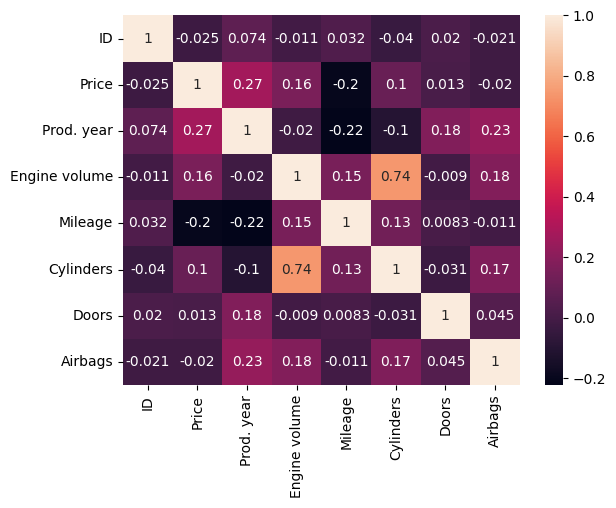

In [100]:
sns.heatmap(df.corr(numeric_only=True),annot=True)